In [1]:
import sys
import umap
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from zadu import zadu
import torch
from pcc import PCC, PCUMAP
from pcc.metrics import Metrics
from pacmap import LocalMAP
from torchdr import UMAP
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

sys.path.append("../benchmark")

from benchmark.datasets import get_available_datasets, DatasetManager

datasets = get_available_datasets()
print(datasets)
manager = DatasetManager()

names = ["krumsiek11", "macosko", "pancreas_baron"]
dataset_data = []
dataset_clusters = []

for dataset_name in names:
    X, y, name = manager.load_dataset(dataset_name)
    X = np.asarray(X)
    dataset_data.append((X, y))


    np.random.seed(0)
    torch.manual_seed(0)



    umap_reducer = UMAP(n_components=10, random_state=0, device='cuda', min_dist=0.2)

    X_umap = umap_reducer.fit_transform(X)
    clusters = []
    n_clusters_list = [4, 8, 16, 32]
    for n_clusters in n_clusters_list:
        kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto") 
        cluster_labels = kmeans.fit_predict(X_umap)
        clusters.append(cluster_labels)

    dataset_clusters.append(clusters)

/home/jacob/miniconda3/envs/dl/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['arcene', 'birthweight', 'breast_cancer', 'cifar', 'cifar100', 'fashion_mnist', 'krumsiek11', 'macosko', 'mammoth', 'mice_protein', 'mnist', 'mouse_msi', 'pancreas_baron', 'pancreas_muraro', 'pancreas_segerstolpe', 'parkinsons', 'paul15', 'pbmc3k', 'pbmc68k', 'qsar_biodeg', 'scvelo_dentategyrus', 'scvelo_pancreas', 'squidpy_visium_hne', 'swiss_roll', 'visium', 'zheng']
[TorchDR] Out of memory encountered, setting backend to 'keops' for UMAPAffinityIn object.


100%|██████████| 1000/1000 [00:01<00:00, 514.18it/s]


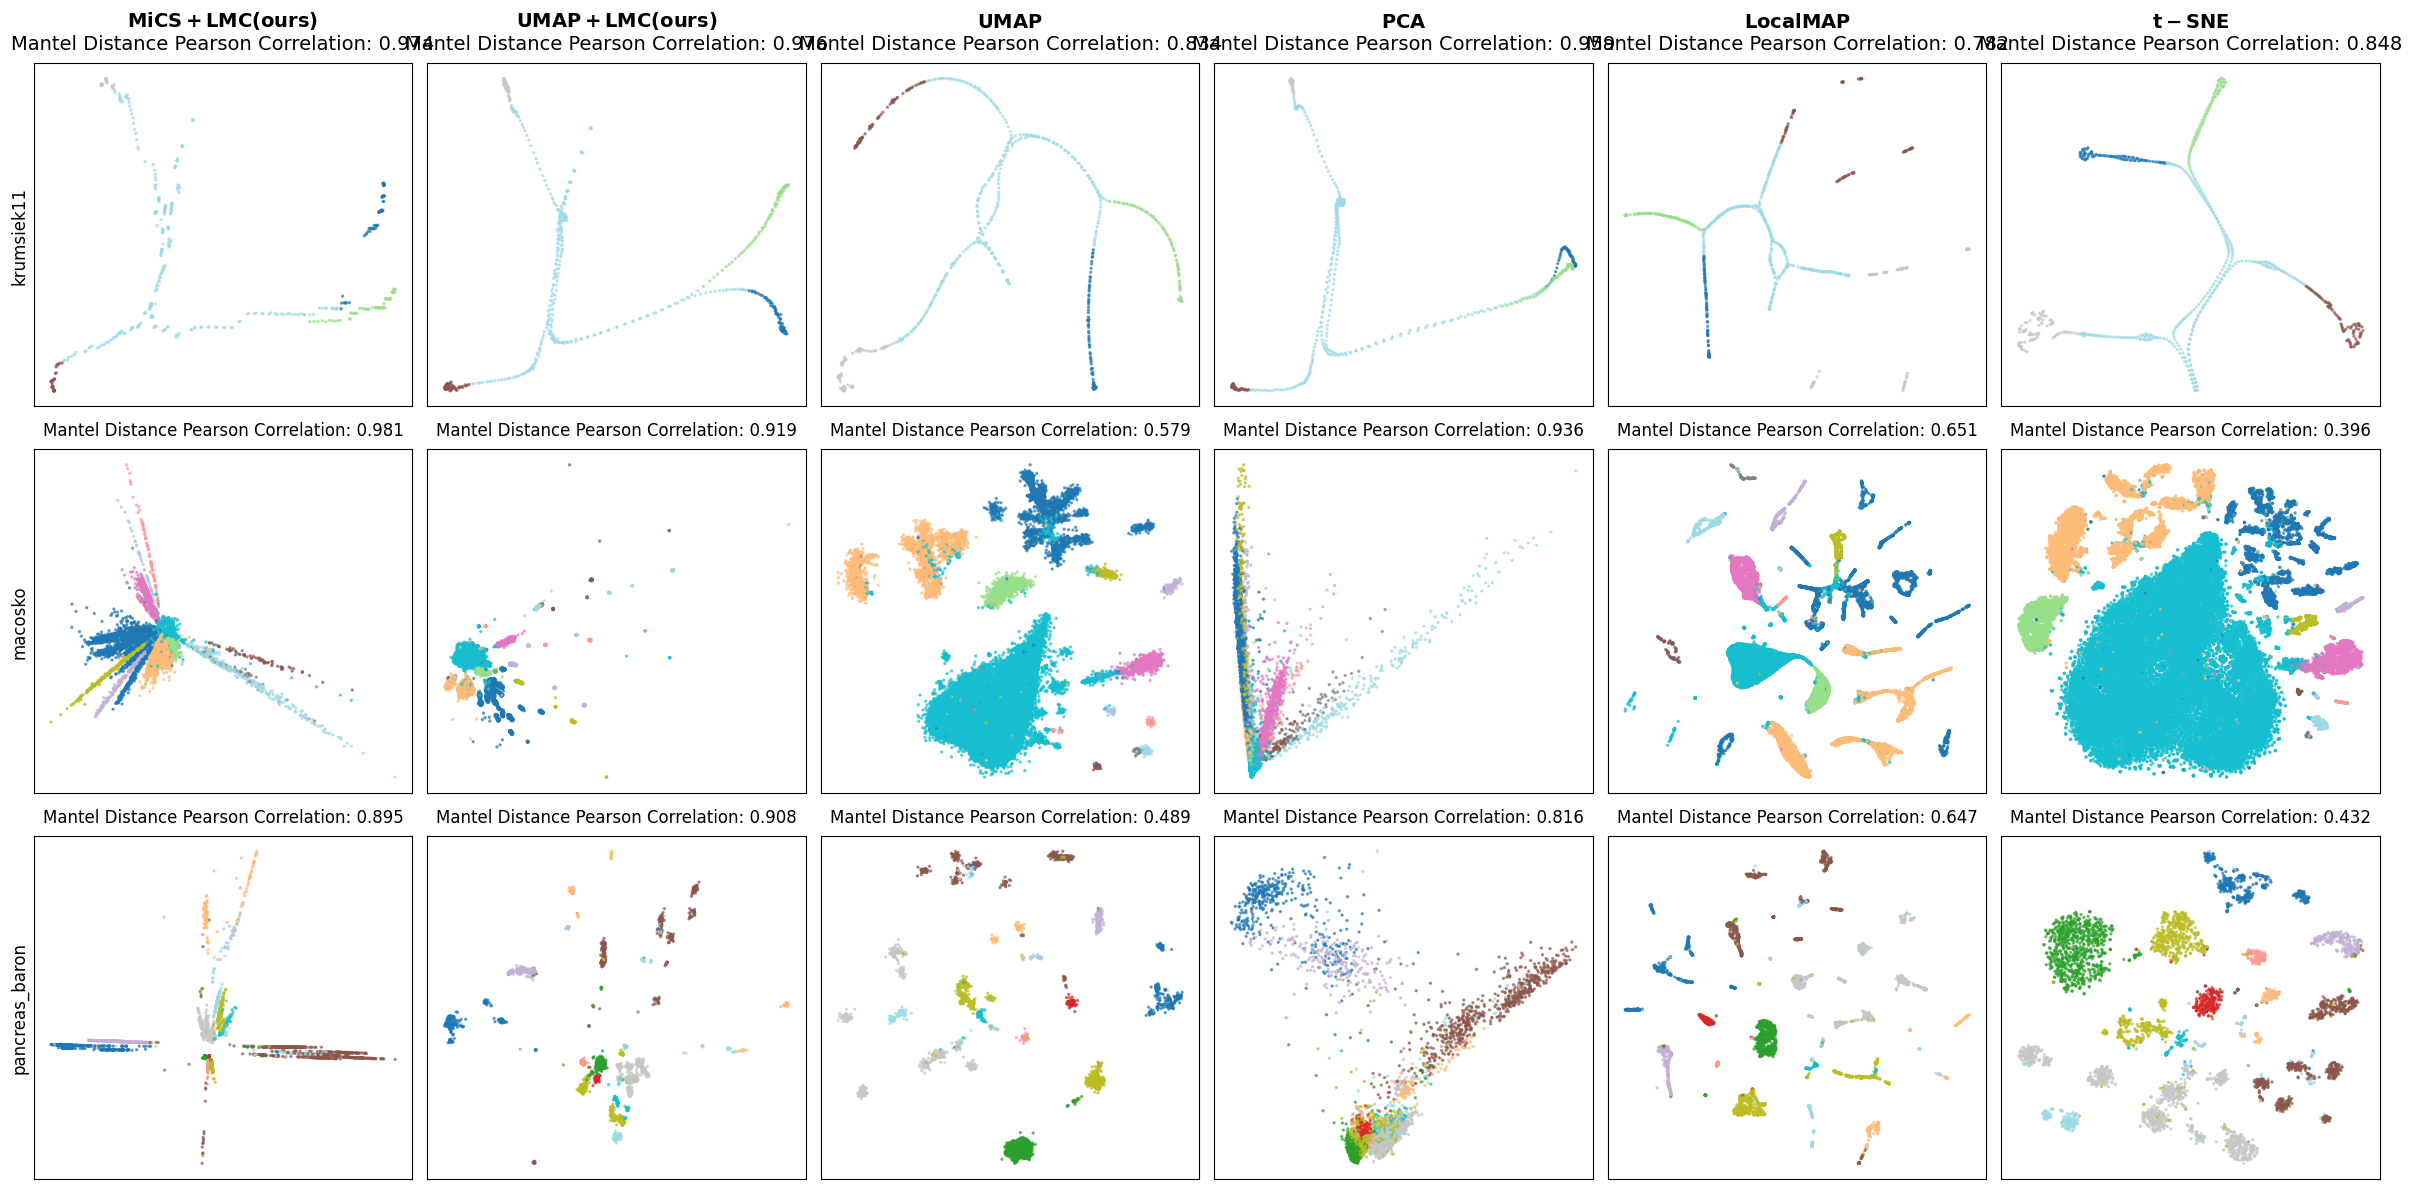

In [6]:
from sklearn.preprocessing import LabelEncoder

# Set up the figure with subplots - one row per dataset
fig, axes = plt.subplots(len(names), 6, figsize=(24, 4*len(names)))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

metrics = []

for idx, ((X, y), clusters, name) in enumerate(zip(dataset_data, dataset_clusters, names)):
    y = LabelEncoder().fit_transform(y)
    # Run dimensionality reduction methods
    pcc_reducer = PCC(n_components=2, num_epochs=1000, num_points=1000, pearson=True, spearman=False, 
                    beta=20, k_epoch=50, temperature=20, batch_size=4096*2*2, sampling="random", 
                    cluster=True)
    pcc_embedding = pcc_reducer.fit_transform(X, clusters)

    pcumap_reducer = PCUMAP(n_components=2, num_points=1000, pearson=True, spearman=False)
    pcumap_embedding = pcumap_reducer.fit_transform(X)

    umap_reducer = UMAP(random_state=42, n_components=2)
    umap_embedding = umap_reducer.fit_transform(X)

    localmap_reducer = LocalMAP(n_components=2, n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0, random_state=42)
    localmap_embedding = localmap_reducer.fit_transform(X, init="pca")

    pca = PCA(n_components=2)
    pca_embedding = pca.fit_transform(X)

    tsne = TSNE(n_components=2, random_state=0)
    tsne_embedding = tsne.fit_transform(X)

    # Calculate metrics
    dataset_metrics = []
    embeddings = [
        (pcc_embedding, "MiCS+LMC (ours)"),
        (pcumap_embedding, "UMAP+LMC (ours)"), 
        (umap_embedding, "UMAP"),
        (pca_embedding, "PCA"),
        (localmap_embedding, "LocalMAP"),
        (tsne_embedding, "t-SNE")
    ]

    for embedding, method_name in embeddings:
        spec = [{"id": "pr"}]
        
        
        scores = zadu.ZADU(spec, X[::20, :]).measure(embedding[::20])
        result = {}
        for item in scores:
            for k, v in item.items():
                result["Mantel Distance Pearson Correlation"] = float(v)


        dataset_metrics.append(float(v))
        
    metrics.append(dataset_metrics)

    # Create scatter plots
    for j, (embedding, method_name) in enumerate(embeddings):
        ax = axes[idx, j]
        
        # Rotate the embedding to maximize horizontal spread
        if embedding.shape[0] > 0:
            # Calculate principal components of the embedding
            pca_rot = PCA(n_components=2)
            embedding_rotated = pca_rot.fit_transform(embedding)
            
            # Calculate the spread in x and y directions
            x_spread = np.ptp(embedding_rotated[:, 0])
            y_spread = np.ptp(embedding_rotated[:, 1])
            
            # If vertical spread is larger, swap the axes
            if y_spread > x_spread:
                embedding_rotated = embedding_rotated[:, ::-1]
                
            scatter = ax.scatter(embedding_rotated[:, 0], embedding_rotated[:, 1], 
                               c=y, cmap='tab20', s=2, alpha=0.6)
        
        if idx == 0:
            ax.set_title(f"$\\mathbf{{{method_name}}}$\nMantel Distance Pearson Correlation: {metrics[idx][j]:.3f}", 
                        fontsize=14, pad=10)
        else:
            ax.set_title(f"Mantel Distance Pearson Correlation: {metrics[idx][j]:.3f}", 
                        fontsize=12, pad=10)
            
        if j == 0:
            ax.set_ylabel(name, fontsize=12)
            
        ax.set_xticks([])
        ax.set_yticks([])
        # Show borders by setting spines visible
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True) 
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_visible(True)

plt.tight_layout()
plt.savefig('Figure_scrna.jpg', dpi=400, format='jpg')

plt.show()

In [17]:
plt.savefig('Figure_scrna.jpg', dpi=400, format='jpg')

<Figure size 640x480 with 0 Axes>